# Optimal Transport in linear ICA applied to Econometrics

#### In this application we test our methodology to find ICs in a simulated price discovery case between distinct markets

In [1]:
# ==============================================================================
# PRICE DISCOVERY VIA STRUCTURAL ICA
# Cell 1: imports, global seed, and the true structure of the DGP
# ==============================================================================
import os, random, itertools, time, warnings
import numpy as np
import pandas as pd
import torch
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import FastICA

from wasserstein_ica import WassersteinICA

SEED = 42

def set_seed(s=SEED):
    """Seed every RNG that can affect a replication."""
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- structural truth: non-diagonal but diagonally dominant B ----------
# Two competing requirements:
#   (i)  B_true must NOT be diagonal. A diagonal B gives a diagonal Omega, so
#        whitening alone recovers the sources and the rotation C degenerates to a
#        signed permutation - a vertex of the search space, not a generic point.
#   (ii) B_true MUST satisfy the identifying assumption used downstream, namely
#        that the shock with maximal impact on market j is shock j. Otherwise the
#        assignment step attaches the right shares to the wrong markets and the
#        reported bias measures the mismatch, not the estimator.
# We therefore draw dense off-diagonals and set each diagonal entry so that the
# column sums equal sqrt(IS_j) exactly, then verify (ii) explicitly.
TARGET_IS = np.array([0.12, 0.24, 0.64])
v = np.sqrt(TARGET_IS)                       # required column sums; sum(v^2) = 1

rng0 = np.random.default_rng(SEED)
for _attempt in range(200):
    off = rng0.uniform(0.10, 0.22, (3, 3)) * rng0.choice([-1.0, 1.0], (3, 3)) * v[None, :]
    np.fill_diagonal(off, 0.0)
    B_TRUE = off.copy()
    for j in range(3):
        B_TRUE[j, j] = v[j] - off[:, j].sum()          # column sum = v_j exactly
    _, _c = linear_sum_assignment(-np.abs(B_TRUE))
    if np.array_equal(_c, np.arange(3)) and np.all(np.diag(B_TRUE) > 0):
        break
else:
    raise RuntimeError("could not draw a diagonally dominant B_TRUE")

OMEGA_TRUE = B_TRUE @ B_TRUE.T
assert np.linalg.eigvalsh(OMEGA_TRUE).min() > 1e-6
assert np.allclose(np.ones(3) @ B_TRUE, v)

# ---------- cointegration: rank 2, hence exactly one common efficient price ----------
BETA  = np.array([[1., 0.], [-1., 1.], [0., -1.]])          # price spreads
ALPHA = np.array([[-0.2, 0.1], [0.1, -0.2], [0.1, 0.1]])    # columns sum to zero
assert np.allclose(ALPHA.sum(0), 0)                          # => alpha_perp prop. to iota
PI = ALPHA @ BETA.T

ev = np.sort(np.abs(np.linalg.eigvals(np.eye(3) + PI)))
assert ev[-1] > 1 - 1e-8 and ev[-2] < 1 - 1e-3               # exactly one unit root

print(f"device = {DEVICE}   |   seed = {SEED}")
print("\nB_true =\n", np.round(B_TRUE, 3))
print(f"\noff-diagonal mass: "
      f"{1 - np.abs(np.diag(B_TRUE)).sum() / np.abs(B_TRUE).sum():.1%}")
print("companion eigenvalues:", np.round(ev, 3))
print("target IS:", TARGET_IS)

device = cpu   |   seed = 42

B_true =
 [[ 0.344 -0.075  0.162]
 [-0.064  0.469  0.174]
 [ 0.066  0.095  0.464]]

off-diagonal mass: 33.2%
companion eigenvalues: [0.7 0.7 1. ]
target IS: [0.12 0.24 0.64]


In [2]:
# ==============================================================================
# Cell 2: DGP, estimation, identification, solvers
# ==============================================================================

def simulate(T, seed, burn=1000):
    """Three cointegrated prices sharing one efficient price; Student-t shocks."""
    rng = np.random.default_rng(seed)
    eps = np.column_stack([rng.standard_t(df, T + burn) / np.sqrt(df / (df - 2.0))
                           for df in (5, 6, 7)])              # unit variance
    u = eps @ B_TRUE.T
    p = np.zeros((T + burn + 1, 3))
    for t in range(T + burn):
        p[t + 1] = p[t] + PI @ p[t] + u[t]
    return p[burn:]                                            # (T+1) x 3


def estimate_vecm(p):
    """OLS with known cointegrating vectors. Returns (residuals, alpha_hat)."""
    dp = np.diff(p, axis=0)
    z  = p[:-1] @ BETA
    dp_c, z_c = dp - dp.mean(0), z - z.mean(0)
    alpha_hat = np.linalg.lstsq(z_c, dp_c, rcond=None)[0].T    # 3 x 2
    return dp_c - z_c @ alpha_hat.T, alpha_hat


def psi_from_alpha(alpha_hat):
    """Long-run impact vector from alpha_perp, normalised so psi @ iota = 1."""
    a_perp = np.linalg.svd(alpha_hat.T)[2][-1]
    return a_perp / (a_perp @ np.ones(3))


def info_share(B, psi):
    """Hasbrouck Information Share from a structural mixing matrix."""
    s = (psi @ B) ** 2
    return s / s.sum()


# ------------------------------------------------------------------------------
# ECONOMIC IDENTIFICATION
# Raw ICA is permutation- and sign-indeterminate. We impose:
#   1. Dominant diagonal  - the shock with maximum impact on market i is labelled
#      shock i, solved as an assignment problem (Hungarian algorithm).
#   2. Positive own impact - a structural innovation raises its own price, so
#      columns with a negative diagonal entry are flipped.
# Both constraints act on the MIXING matrix B (u = B eps), never on the unmixing
# matrix, so they are shared verbatim by OT-ICA and FastICA.
# ------------------------------------------------------------------------------
def identify(B_raw):
    """Apply the permutation and sign constraints to a raw mixing matrix."""
    B_raw = np.asarray(B_raw, dtype=np.float64)
    _, col_ind = linear_sum_assignment(-np.abs(B_raw))   # maximise |B_ii|
    B_perm = B_raw[:, col_ind]
    return B_perm * np.sign(np.diag(B_perm))[None, :]


def ot_mixing(u, seed, n_restarts=24, defl_iter=200, stiefel_iter=300, lr=0.5):
    """OT-ICA on VECM residuals u (T x d). Returns the raw mixing matrix."""
    set_seed(seed)
    d = u.shape[1]
    model = WassersteinICA(torch.tensor(u.T, dtype=torch.float32, device=DEVICE))
    model.whiten()

    ws = []
    for _ in range(d):
        prev = torch.stack(ws) if ws else None
        w, _ = model.optimize_wasserstein2(prev_components=prev, continuous=True,
                                           max_iter=defl_iter, lr=0.1,
                                           n_restarts=n_restarts)
        ws.append(w)

    W_est = model.optimize_symmetric(n_components=d, optimizer="stiefel",
                                     init_w=torch.stack(ws), use_sinkhorn=False,
                                     max_iter=stiefel_iter, lr=lr, batch_size=1024)

    W_total = torch.matmul(W_est, model.W_white).detach().cpu().numpy().astype(np.float64)
    return np.linalg.inv(W_total)


def fi_mixing(u, seed, max_iter=10000, tol=1e-5):
    """FastICA baseline on u (T x d). Returns (raw mixing matrix, converged flag)."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        ica = FastICA(n_components=u.shape[1], whiten="unit-variance", fun="logcosh",
                      max_iter=max_iter, tol=tol, random_state=seed)
        ica.fit(u)
        converged = not any("did not converge" in str(w.message) for w in caught)
    return ica.mixing_, converged


def cholesky_is(Omega, psi):
    """Hasbrouck bounds: Information Shares BY MARKET under every ordering.

    P @ Omega @ P.T factorises the reordered system, so P.T @ L restores the rows
    to market order but leaves the columns (shocks) in permuted order. Both axes
    must be restored, or the shares come back attached to the wrong markets.
    """
    out = []
    for perm in itertools.permutations(range(3)):
        P = np.eye(3)[list(perm)]
        L = np.linalg.cholesky(P @ Omega @ P.T)
        M = P.T @ L                       # rows -> market order
        Mc = np.empty_like(M)
        Mc[:, list(perm)] = M             # columns -> market order
        out.append(info_share(Mc, psi))
    return np.array(out)


# ------------------------------ pipeline check ------------------------------
# Validates the DGP, the target shares and the identification convention against
# each other before any estimation. Catches label permutation at zero cost.
psi_true = np.ones(3) / 3.0
assert np.allclose(info_share(B_TRUE, psi_true), TARGET_IS), "target shares inconsistent"
assert np.allclose(identify(B_TRUE), B_TRUE), "identify() disagrees with the truth"

_chk = cholesky_is(OMEGA_TRUE, psi_true)
assert np.all(_chk.min(0) <= TARGET_IS + 1e-9) and np.all(_chk.max(0) >= TARGET_IS - 1e-9), \
    "Cholesky bounds do not bracket the truth"

print("pipeline check passed")
print("Cholesky bounds at the true Omega:")
for k in range(3):
    print(f"  market {k+1}: true {TARGET_IS[k]:.2f}   "
          f"range [{_chk.min(0)[k]:.3f}, {_chk.max(0)[k]:.3f}]")

pipeline check passed
Cholesky bounds at the true Omega:
  market 1: true 0.12   range [0.012, 0.431]
  market 2: true 0.24   range [0.068, 0.603]
  market 3: true 0.64   range [0.097, 0.849]


In [3]:
# ==============================================================================
# Cell 3: Monte Carlo over replications
# Each run: simulate cointegrated prices -> estimate the VECM by OLS with known
# cointegrating vectors -> recover the rotation from the residuals with each
# solver -> identify -> compute Information Shares. Cholesky bounds over all 3!
# orderings quantify the ordering-dependence that structural ICA removes.
# ==============================================================================
N_SIM, T = 500, 5000          # set N_SIM = 5 for a smoke test first
SAVE_CSV = "price_discovery_mc.csv"

rows, n_fi_fail = [], 0
t0 = time.time()

for s in range(N_SIM):
    seed_s = SEED + s

    p = simulate(T, seed=seed_s)
    u, alpha_hat = estimate_vecm(p)
    psi   = psi_from_alpha(alpha_hat)
    Omega = np.cov(u, rowvar=False)
    ch    = cholesky_is(Omega, psi)

    B_ot = identify(ot_mixing(u, seed_s))

    B_fi_raw, ok = fi_mixing(u, seed_s)
    n_fi_fail += (not ok)
    B_fi = identify(B_fi_raw)

    rows.append(dict(sim=s, method="OT-ICA",
                     **dict(zip("123", info_share(B_ot, psi)))))
    rows.append(dict(sim=s, method="FastICA",
                     **dict(zip("123", info_share(B_fi, psi)))))
    rows.append(dict(sim=s, method="Chol-min", **dict(zip("123", ch.min(0)))))
    rows.append(dict(sim=s, method="Chol-max", **dict(zip("123", ch.max(0)))))

    if (s + 1) % 25 == 0 or s == 0:
        el = time.time() - t0
        print(f"  {s + 1:4d}/{N_SIM}   {el / 60:5.1f} min elapsed   "
              f"eta {(el / (s + 1)) * (N_SIM - s - 1) / 60:5.1f} min")

res = pd.DataFrame(rows)
res.to_csv(SAVE_CSV, index=False)          # survives a kernel crash

print(f"\ndone in {(time.time() - t0) / 60:.1f} min   ->  {SAVE_CSV}")
if n_fi_fail:
    print(f"NOTE: FastICA hit the iteration cap in {n_fi_fail}/{N_SIM} runs")

# sanity: means should sit near TARGET_IS, not a permutation of it
_m = res.loc[res.method == "OT-ICA", ["1", "2", "3"]].values.mean(0)
print("OT-ICA mean shares:", np.round(_m, 4), " target:", TARGET_IS)
if np.abs(_m - TARGET_IS).max() > 0.05:
    print("WARNING: shares are far from target - check for label permutation "
          "before interpreting the table.")

     1/500     0.0 min elapsed   eta  20.0 min
    25/500     1.2 min elapsed   eta  22.2 min
    50/500     2.2 min elapsed   eta  19.4 min
    75/500     3.1 min elapsed   eta  17.7 min
   100/500     4.1 min elapsed   eta  16.4 min
   125/500     5.1 min elapsed   eta  15.3 min
   150/500     6.1 min elapsed   eta  14.2 min
   175/500     7.0 min elapsed   eta  13.1 min
   200/500     8.0 min elapsed   eta  12.0 min
   225/500     8.9 min elapsed   eta  10.8 min
   250/500     9.8 min elapsed   eta   9.8 min
   275/500    10.9 min elapsed   eta   8.9 min
   300/500    12.1 min elapsed   eta   8.0 min
   325/500    13.2 min elapsed   eta   7.1 min
   350/500    14.3 min elapsed   eta   6.1 min
   375/500    15.3 min elapsed   eta   5.1 min
   400/500    16.1 min elapsed   eta   4.0 min
   425/500    17.0 min elapsed   eta   3.0 min
   450/500    18.3 min elapsed   eta   2.0 min
   475/500    19.0 min elapsed   eta   1.0 min
   500/500    20.1 min elapsed   eta   0.0 min

done in 20.1

In [4]:
# ==============================================================================
# Cell 4: results table (console + LaTeX for the paper)
# ==============================================================================
# res = pd.read_csv(SAVE_CSV)   # uncomment to reload without rerunning Cell 3

get = lambda m: res.loc[res.method == m, ["1", "2", "3"]].values
ot, fi = get("OT-ICA"), get("FastICA")
lo, hi = get("Chol-min").mean(0), get("Chol-max").mean(0)

print("=" * 78)
print(f"Information Share recovery   |   {N_SIM} runs, T = {T}")
print("=" * 78)
print(f"{'Market':<8}{'True':>7}{'OT-ICA':>19}{'FastICA':>19}{'Cholesky range':>21}")
print("-" * 78)
for k in range(3):
    print(f"{k + 1:<8}{TARGET_IS[k]:>7.2f}"
          f"{ot[:, k].mean():>12.4f} ({ot[:, k].std():.4f})"
          f"{fi[:, k].mean():>12.4f} ({fi[:, k].std():.4f})"
          f"{'':>6}[{lo[k]:.3f}, {hi[k]:.3f}]")
print("=" * 78)

for tag, E in [("OT-ICA", ot - TARGET_IS), ("FastICA", fi - TARGET_IS)]:
    print(f"  {tag:8s} bias {np.round(E.mean(0), 4)}   "
          f"RMSE {np.round(np.sqrt((E ** 2).mean(0)), 4)}   "
          f"max |bias| {np.abs(E.mean(0)).max():.4f}")
print(f"  Cholesky bound width per market: {np.round(hi - lo, 3)}")

# ---------------------------- LaTeX ----------------------------
print("\n" + r"\begin{tabular}{@{}lcccc@{}}")
print(r"\toprule")
print(r"Market & True & OT-ICA & FastICA & Cholesky range \\")
print(r"\midrule")
for k in range(3):
    print(f"{k + 1} & {TARGET_IS[k]:.2f} "
          f"& {ot[:, k].mean():.4f}\\,({ot[:, k].std():.4f}) "
          f"& {fi[:, k].mean():.4f}\\,({fi[:, k].std():.4f}) "
          f"& $[{lo[k]:.3f},\\,{hi[k]:.3f}]$ \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")

Information Share recovery   |   500 runs, T = 5000
Market     True             OT-ICA            FastICA       Cholesky range
------------------------------------------------------------------------------
1          0.12      0.1197 (0.0223)      0.1196 (0.0217)      [0.012, 0.430]
2          0.24      0.2419 (0.0393)      0.2423 (0.0462)      [0.069, 0.603]
3          0.64      0.6385 (0.0447)      0.6381 (0.0514)      [0.098, 0.849]
  OT-ICA   bias [-0.0003  0.0019 -0.0015]   RMSE [0.0223 0.0394 0.0448]   max |bias| 0.0019
  FastICA  bias [-0.0004  0.0023 -0.0019]   RMSE [0.0217 0.0462 0.0514]   max |bias| 0.0023
  Cholesky bound width per market: [0.418 0.534 0.751]

\begin{tabular}{@{}lcccc@{}}
\toprule
Market & True & OT-ICA & FastICA & Cholesky range \\
\midrule
1 & 0.12 & 0.1197\,(0.0223) & 0.1196\,(0.0217) & $[0.012,\,0.430]$ \\
2 & 0.24 & 0.2419\,(0.0393) & 0.2423\,(0.0462) & $[0.069,\,0.603]$ \\
3 & 0.64 & 0.6385\,(0.0447) & 0.6381\,(0.0514) & $[0.098,\,0.849]$ \\
\bottomrul

In [ ]:
# ==============================================================================
# Cell 4b: sign test, OT-ICA vs FastICA, paired by replication (Table 8 supp)
# Pairing unit: `sim`, already an explicit column in `res`. Per market, compares
# |estimated share - true share| (absolute error against TARGET_IS) between the
# two solvers on the same replication -- this is the natural paired quantity
# given the paper's claim is a near-tie ("both solvers recover ... bias below
# 0.003"), not a directional OT-ICA-wins claim as in the ICA benchmarks.
# ==============================================================================
from scipy.stats import binomtest

def market_abs_err(df, method, market_col, target):
    sub = df[df.method == method].set_index("sim")
    return (sub[market_col] - target).abs()

sign_rows_is = []
for k in range(3):
    col = str(k + 1)
    e_ot = market_abs_err(res, "OT-ICA", col, TARGET_IS[k])
    e_fi = market_abs_err(res, "FastICA", col, TARGET_IS[k])
    piv = pd.DataFrame({"OT-ICA": e_ot, "FastICA": e_fi}).dropna()
    mask = piv["OT-ICA"] != piv["FastICA"]
    n = int(mask.sum())
    wins = int((piv.loc[mask, "OT-ICA"] < piv.loc[mask, "FastICA"]).sum())
    p = binomtest(wins, n, 0.5, alternative="two-sided").pvalue if n > 0 else np.nan
    sign_rows_is.append({"Market": k + 1, "n_pairs": n, "wins_OT-ICA": wins,
                         "losses_OT-ICA": n - wins, "p_value": p})

sign_is = pd.DataFrame(sign_rows_is)
print(f"Sign test, |error| OT-ICA vs FastICA, paired by replication (N_SIM={N_SIM}):")
print(sign_is.to_string(index=False))
print("\nNote: the paper's claim here is a near-tie between solvers (both track "
      "TARGET_IS with bias < 0.003), so a significant p-value in either direction "
      "on a single market is a comment on estimator variance, not a headline claim "
      "-- the actually decisive comparison in this application is against the "
      "Cholesky-ordering bounds (deterministic, no sign test applicable).")

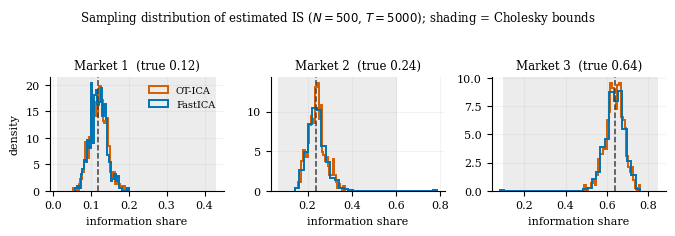

In [5]:
# ==============================================================================
# Cell 5 (optional): sampling distribution of the estimated shares
# ==============================================================================
import matplotlib.pyplot as plt

PALETTE = {"OT-ICA": "#D55E00", "FastICA": "#0173B2"}
plt.rcParams.update({"font.family": "serif", "font.size": 8,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "savefig.dpi": 400, "savefig.bbox": "tight"})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.2))
for k, ax in enumerate(axes):
    for tag, D in [("OT-ICA", ot), ("FastICA", fi)]:
        ax.hist(D[:, k], bins=32, density=True, histtype="step",
                lw=1.4, color=PALETTE[tag], label=tag)
    ax.axvspan(lo[k], hi[k], color="0.6", alpha=0.18, lw=0)
    ax.axvline(TARGET_IS[k], color="0.25", ls="--", lw=1.1)
    ax.set_title(f"Market {k + 1}  (true {TARGET_IS[k]:.2f})", fontsize=8.5)
    ax.set_xlabel("information share")
    ax.grid(alpha=0.15)
axes[0].set_ylabel("density")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle(f"Sampling distribution of estimated IS ($N={N_SIM}$, $T={T}$); "
             "shading = Cholesky bounds", fontsize=8.5, y=1.04)
plt.tight_layout()
plt.savefig("econ_is_distribution.pdf")
plt.show()

### Economic Identification Strategy
Unlike the statistical output of raw ICA, which is permutation and sign indeterminate, we impose two strict economic constraints to recover the structural parameters:

1. **Dominant Diagonal (Permutation):** We strictly enforce that the structural shock assigned to Market $i$ must be the one that contributes the maximum variance to that specific market. This is implemented via the Hungarian Algorithm to solve the assignment problem.
2. **Positive Impact (Sign):** We assume positive spillovers, meaning a structural innovation (good news) must have a positive initial impact on its own price. Negative coefficients are sign-flipped.